In [7]:
import pandas as pd
import numpy as np
import seaborn as sns

In [25]:
df=pd.read_csv('df_oh.csv')

In [26]:

print("X_train Before:",df.shape)

df=df.drop_duplicates()
print("X_train after:",df.shape)


X_train Before: (891, 12)
X_train after: (891, 12)


In [31]:
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S


In [32]:
df.describe().sum()

PassengerId    3824.353842
Survived        893.870431
Pclass          906.144713
Age             918.005236
SibSp           901.625751
Parch           898.187651
Fare           1054.527438
dtype: float64

In [33]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [34]:

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [35]:
from sklearn.impute import SimpleImputer
S1=SimpleImputer(strategy='mean')

In [36]:
df=df.drop('Cabin',axis=1)

In [37]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [38]:
from sklearn.impute import SimpleImputer
mean_imputer=SimpleImputer(strategy='mean')
X_train['Age_imputed']=mean_imputer.fit_transform(X_train[['Age']]).astype('int64')
X_test['Age_imputed']=mean_imputer.transform(X_test[["Age"]]).astype('int64')
X_train.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         2
Age_imputed      0
dtype: int64

In [39]:
X_train['Age_imputed_with_random_val']=X_train[['Age']]
X_train['Age_imputed_with_random_val'][X_train['Age_imputed_with_random_val'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\2097978224.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed_with_random_val'][X_train['Age_imputed_with_random_val'].isnull()]=X_train['Age'].dropna().sample(X_train['A

In [40]:
# imputed with random number
X_train['Age_imputed_with_random_val'] = X_train[['Age']]
X_train['Age_imputed_with_random_val'][X_train['Age_imputed_with_random_val'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\3379749836.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed_with_random_val'][X_train['Age_imputed_with_random_val'].isnull()] = X_train['Age'].dropna().sample(X_train[

In [41]:
# imputed with random number
X_test['Age_imputed_with_random_val'] = X_test[['Age']]
X_test['Age_imputed_with_random_val'][X_test['Age_imputed_with_random_val'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\3793685653.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_test['Age_imputed_with_random_val'][X_test['Age_imputed_with_random_val'].isnull()] = X_test['Age'].dropna().sample(X_test['Age

C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\4183982795.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Imputed',hist=False)
C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\4183982795.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed

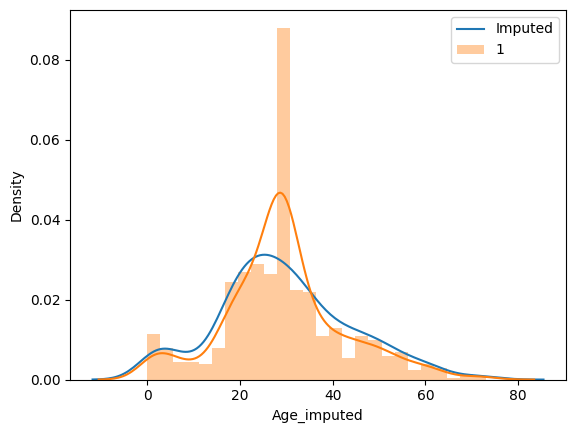

In [42]:
import matplotlib.pyplot as plt
sns.distplot(X_train['Age'],label='Imputed',hist=False)
sns.distplot(X_train['Age_imputed'],label=1)
plt.legend()
plt.show()

In [43]:
from sklearn.impute import SimpleImputer
mean_imputer= SimpleImputer(strategy='most_frequent')
X_train[['Embarked_mode']]=mean_imputer.fit_transform(X_train[['Embarked']])
X_test[['Embarked_mode']]=mean_imputer.transform(X_test[["Embarked"]])
X_train.isnull().sum()

PassengerId                      0
Pclass                           0
Name                             0
Sex                              0
Age                            140
SibSp                            0
Parch                            0
Ticket                           0
Fare                             0
Cabin                          553
Embarked                         2
Age_imputed                      0
Age_imputed_with_random_val      0
Embarked_mode                    0
dtype: int64

C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\1075186872.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_test['Age'],label='Original',hist=False)
C:\Users\Kinza\AppData\Local\Temp\ipykernel_1840\1075186872.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_test['Age

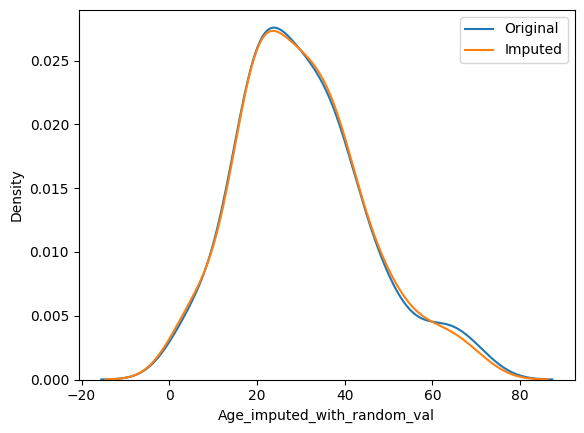

In [44]:
import matplotlib.pyplot as plt
# sns.distplot(X_train['Age'],label='Imputed',hist=False)
# sns.distplot(X_train['Age_imputed'],label=1)
# plt.legend()
# plt.show()
sns.distplot(X_test['Age'],label='Original',hist=False)
sns.distplot(X_test['Age_imputed_with_random_val'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [45]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_imputed',
       'Age_imputed_with_random_val', 'Embarked_mode'],
      dtype='object')

In [46]:
print("X_train Before:",X_train.shape)
print("X_test Before:",X_test.shape)

X_train=X_train.drop_duplicates()
X_test=X_test.drop_duplicates()
print("X_train after:",X_train.shape)
print("X_test after:",X_test.shape)

X_train Before: (712, 14)
X_test Before: (179, 14)
X_train after: (712, 14)
X_test after: (179, 14)


In [47]:
# X_train=X_train.drop(['PassengerId','Age','Name','Ticket','Cabin','Embarked','Age_imputed'],axis=1)
# X_test=X_test.drop(['PassengerId','Age','Name','Ticket','Cabin','Embarked','Age_imputed'],axis=1)
# X_train.columns

In [48]:
X_train=X_train[[ 'Pclass', 'Sex', 'SibSp', 'Parch','Fare','Age_imputed_with_random_val', 'Embarked_mode']]
X_test=X_test[[ 'Pclass', 'Sex','SibSp', 'Parch','Fare','Age_imputed_with_random_val', 'Embarked_mode']]
X_train

,Pclass,Sex,SibSp,Parch,Fare,Age_imputed_with_random_val,Embarked_mode
331,1,male,0,0,28.5000,45.5,S
733,2,male,0,0,13.0000,23.0,S
382,3,male,0,0,7.9250,32.0,S
704,3,male,1,0,7.8542,26.0,S
813,3,female,4,2,31.2750,6.0,S
...,...,...,...,...,...,...,...
106,3,female,0,0,7.6500,21.0,S
270,1,male,0,0,31.0000,36.0,S
860,3,male,2,0,14.1083,41.0,S
435,1,female,1,2,65.6344,14.0,S


In [49]:
X_train=X_train.rename(columns={'Age_imputed_with_random_val':'Age','Embarked_mode':'Embarked'})
X_test=X_test.rename(columns={'Age_imputed_with_random_val':'Age','Embarked_mode':'Embarked'})
print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)

(712, 7) (712,) (179, 7) (179,)


In [50]:
X_train.to_csv('X_train_mvh.csv',index=False)
X_test.to_csv('X_test_mvh.csv',index=False)
Y_train.to_csv('Y_train.csv',index=False)
Y_test.to_csv('Y_test.csv',index=False)